# H&M Recommendation System  Project

## 1.Motivation and clear Question

Online fashion platforms such as H&M offer thousands of products, making it difficult for customers to quickly find items they actually want. Personalized recommendation systems help solve this problem by suggesting products that match each customer’s interests and shopping history. In this project, we use H&M transaction data to explore how past purchases and product information can be used to generate useful recommendations. Our goal is to understand customer preferences and design a system that can make more relevant and personalized suggestions.     

Question: How can we use historical purchase data and product information to recommend the most relevant items to each H&M customer?       

Task:
Given users’ historical purchase behaviors and static user/item attributes, the goal is to predict the top 12 items each test user is most likely to purchase in a future 7 days time window.
Evaluation: MAP@K

Data from Kaggle: https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations
    
There are 'customer.csv','articles.csv','transactions.csv' 

## 2. Data Preparation

### 2.1 Data Loading and Analysis

In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from tqdm import tqdm

In [3]:
from pathlib import Path

path = 'data/'
art = f'{path}articles.csv'
cus = f'{path}customers.csv'
tran = f'{path}transactions_train.csv'
sub_path = f'{path}sample_submission.csv'

In [4]:
df = pd.read_csv(tran, dtype= {'customer_id':str, 'article_id':str}, parse_dates = ['t_dat'])
df_art = pd.read_csv(art, dtype = {'article_id':str})
df_cus = pd.read_csv(cus, dtype= {'customer_id':str})
df_sub = pd.read_csv(sub_path, dtype = {'customer_id':str})
df.head(5)

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0685687004,0.016932,2


In [5]:
df.shape

(31788324, 5)

In [5]:
df_cus.head(3)

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...


In [6]:
df_art.head(3)

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.


In [8]:
'''
mapping IDs. It is necessary because many recommendation system models 
(such as matrix factorization, embeddings, and neural networks) require user IDs and item IDs 
to be represented as continuous integer indices starting from 0, with no gaps.

'''
ALL_CUSTOMERS = df_cus['customer_id'].drop_duplicates().tolist()
ALL_ARTICLES = df_art['article_id'].drop_duplicates().tolist()

CUSTOMER_TO_USER = {cus: u for u, cus in enumerate(ALL_CUSTOMERS)}
USER_TO_CUSTOMER = {u: cus for u, cus in enumerate(ALL_CUSTOMERS)}

ARTICLE_TO_ITEM = {art: i for i, art in enumerate(ALL_ARTICLES)}
ITEM_TO_ARTICLE = {i: art for i, art in enumerate(ALL_ARTICLES)}

df['user_id'] = df['customer_id'].map(CUSTOMER_TO_USER).astype('int32')
df['item_id'] = df['article_id'].map(ARTICLE_TO_ITEM).astype('int32')

df_sub['user_id'] = df_sub['customer_id'].map(CUSTOMER_TO_USER).astype('int32')

In [9]:
num_users = len(CUSTOMER_TO_USER)
num_items = len(ARTICLE_TO_ITEM)
print(f"num of users = {num_users},num of items = {num_items}")

num of users = 1371980,num of items = 105542


In [9]:
df.head(3)

,t_dat,customer_id,article_id,price,sales_channel_id,user_id,item_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2,2,40179
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2,2,10520
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0505221004,0.015237,2,7,6387


In [10]:
## Are The customers long-tail? most of them only buy few articles.
user_cnt = df.groupby('customer_id').size()
user_cnt.describe() 
# while many users have limited purchase histories, a substantial portion of users have sufficient interactions to support personalized recommendations.#User purchase behavior is moderately long-tailed

count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
dtype: float64

In [11]:
item_cnt = df.groupby(['article_id']).size()
item_cnt.describe()
 #Item popularity is extremely long-tailed. 

count    104547.000000
mean        304.057735
std         791.266060
min           1.000000
25%          14.000000
50%          65.000000
75%         286.000000
max       50287.000000
dtype: float64

In [10]:
last_day = df['t_dat'].max()
last_week_day = last_day.weekday()
first_day = df['t_dat'].min()
first_week_day = first_day.weekday()
print(f'The last day in the data set is {last_day},It is a {last_week_day} weekday')
print(f'The last day in the data set is {first_day},It is a {first_week_day} weekday')

# The last day in our list is 2020-09-22, this is a Tuesday. We are using Monday as the start day for every week.
FIRST_DAY_OF_LAST_WEEK = last_day - pd.Timedelta(days = 6)
print(FIRST_DAY_OF_LAST_WEEK)
#a week is defined as [first day , last day)

The last day in the data set is 2020-09-22 00:00:00,It is a 1 weekday
The last day in the data set is 2018-09-20 00:00:00,It is a 3 weekday
2020-09-16 00:00:00


### 2.2 itemcf recall

In [11]:
import math
import pandas as pd
import numpy as np
from collections import defaultdict
from tqdm import tqdm

def time_decay(delta_days, half_life=7):
    return 0.5 ** (delta_days / half_life)

In [12]:
def itemcf(history_df,
    topk=50,max_user_items=20,item_sim_topk=100,
    start_date=None,user_col="user_id",item_col="item_id",date_col="t_dat",):
    hist = history_df.copy()
    hist[date_col] = pd.to_datetime(hist[date_col])

    hist = hist.sort_values([user_col, date_col, item_col])

    user_item_time = (
        hist.groupby(user_col)[[item_col, date_col]]
        .apply(lambda x: list(zip(x[item_col], x[date_col]))[-max_user_items:])
    )
    item_sim = defaultdict(lambda: defaultdict(float))
    item_cnt = defaultdict(int)

    # 1. build item-item similarity
    for u, item_time_list in tqdm(user_item_time.items(), desc="Build ItemCF"):
        items = [i for i, _ in item_time_list]
        times = [t for _, t in item_time_list]
        L = len(items)

        for i in range(L):
            item_i = items[i]
            time_i = times[i]
            item_cnt[item_i] += 1

            for j in range(L):
                if i == j:
                    continue

                item_j = items[j]
                time_j = times[j]

                if item_i == item_j:
                    continue

                delta = abs((time_i - time_j).days)

                loc_weight = 1.0 / (1 + abs(i - j))

                # the more recent, we should give more weight
                decay_weight = time_decay(delta)

                item_sim[item_i][item_j] += loc_weight * decay_weight

    for i, related_items in item_sim.items():
        for j in related_items:
            item_sim[i][j] /= math.sqrt(item_cnt[i] * item_cnt[j])

    # 3. keep topk similar items for each item
    item_sim = {
        i: dict(sorted(related.items(), key=lambda x: x[1], reverse=True)[:item_sim_topk])
        for i, related in item_sim.items()
    }

    # 4. recall candidates for each user
    rows = []
    for u, item_time_list in tqdm(user_item_time.items(), desc="Recall ItemCF"):
        user_items = [i for i, _ in item_time_list]
        scores = defaultdict(float)

        for item in user_items:
            if item not in item_sim:
                continue

            for j, sim in item_sim[item].items():
                scores[j] += sim

        rec_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:topk]

        for item_id, score in rec_items:
            rows.append([u, item_id, score])

    cand = pd.DataFrame(rows, columns=[user_col, item_col, "score"])

    return cand


#### 2.3. Training data split and preparation

After we use User-CF to generate some candidates. We should divide the data into several weeks, create a label for each week for our neural network training in the following steps, 1 means (user, item) candidate hits the prediction. Use the previous week to predict the next week. The last week is the validation dataset.

In [15]:
def gen_train_valid(df, n_windows, n_neg, itemcf, valid_start_date):
    df = df.copy()
    df["t_dat"] = pd.to_datetime(df["t_dat"])
    df = df.sort_values(["t_dat", "user_id", "item_id"])

    valid_start_date = pd.to_datetime(valid_start_date)
    all_items = df["item_id"].unique()
    rng = np.random.default_rng(42)

    train_list = []
    valid_list = []
    for i in range(n_windows + 1):
        # i = 0 valid, i > 0 train
        label_start = valid_start_date - pd.Timedelta(days=7 * i)
        label_end = label_start + pd.Timedelta(days=7)

        label_df = df[(df["t_dat"] >= label_start) &(df["t_dat"] < label_end)]

        history_df = df[df["t_dat"] < label_start]

        # pos samples
        pos = label_df[["user_id", "item_id"]].drop_duplicates()
        pos["label"] = 1
        pos["window"] = i

        # cancidates：use history to make itemcf recall
        cand = (itemcf(history_df)[["user_id", "item_id", "score"]].drop_duplicates(["user_id", "item_id"]).reset_index(drop=True))

        # neg samples:recall but not bought in next week
        pos_pairs = set(zip(pos["user_id"], pos["item_id"]))
        cand["_pair"] = list(zip(cand["user_id"], cand["item_id"]))
        neg_pool = cand[~cand["_pair"].isin(pos_pairs)].drop(columns="_pair")
        neg_list = []
        for u, g in pos.groupby("user_id"):
            k = len(g) * n_neg

            user_neg = neg_pool[neg_pool["user_id"] == u]["item_id"].unique()

            if len(user_neg) >= k:
                neg_items = rng.choice(user_neg, size=k, replace=False)
            else:
                neg_items = list(user_neg)

                bought = set(g["item_id"])
                while len(neg_items) < k:
                    item = rng.choice(all_items)
                    if item not in bought and item not in neg_items:
                        neg_items.append(item)

            for item in neg_items:
                neg_list.append([u, item, 0, i])
        neg = pd.DataFrame(
            neg_list,
            columns=["user_id", "item_id", "label", "window"])

        samples = pd.concat([pos, neg], ignore_index=True)

        if i == 0:
            valid_list.append(samples)
        else:
            train_list.append(samples)

    train_df = pd.concat(train_list, ignore_index=True)
    valid_df = pd.concat(valid_list, ignore_index=True)

    X_train = train_df[["user_id", "item_id", "window"]]
    y_train = train_df["label"]

    X_valid = valid_df[["user_id", "item_id", "window"]]
    y_valid = valid_df["label"]

    return X_train, y_train, X_valid, y_valid
        

In [22]:
df["t_dat"] = pd.to_datetime(df["t_dat"])

TRAIN_WEEKS = 7
VALID_WEEKS = 1

last_day = df["t_dat"].max()

valid_week_start = last_day - pd.Timedelta(days=6)

train_week_start = valid_week_start - pd.Timedelta(weeks=TRAIN_WEEKS)

df_small = df[df["t_dat"] >= train_week_start].copy()

print("last_day:", last_day)
print("valid_week_start:", valid_week_start)
print("train_week_start:", train_week_start)
print(df_small["t_dat"].min(), df_small["t_dat"].max())

last_day: 2020-09-22 00:00:00
valid_week_start: 2020-09-16 00:00:00
train_week_start: 2020-07-29 00:00:00
2020-07-29 00:00:00 2020-09-22 00:00:00


In [24]:
X_train, y_train, X_valid, y_valid = gen_train_valid(
    df = df_small,
    n_windows=2,
    n_neg=10,
    itemcf=itemcf,
    valid_start_date=valid_week_start)

Build ItemCF: 350008it [00:11, 29416.16it/s]
Recall ItemCF: 350008it [00:29, 11726.15it/s]
Build ItemCF: 317672it [00:09, 31920.79it/s]
Recall ItemCF: 317672it [00:28, 11079.37it/s]
Build ItemCF: 279667it [00:08, 34890.45it/s]
Recall ItemCF: 279667it [00:27, 10051.04it/s]


In [26]:
from pathlib import Path

sample_dir = Path('samples')

In [28]:
train_samples = X_train.copy()
train_samples["label"] = y_train.values

valid_samples = X_valid.copy()
valid_samples["label"] = y_valid.values

train_samples.to_parquet(sample_dir/"train_samples.parquet", index=False)
valid_samples.to_parquet(sample_dir/"valid_samples.parquet", index=False)

In [30]:
import pandas as pd

train_samples = pd.read_parquet(sample_dir/"train_samples.parquet")
valid_samples = pd.read_parquet(sample_dir/"valid_samples.parquet")

In [32]:
X_train = train_samples[["user_id", "item_id"]].values.astype("int32")
X_valid = valid_samples[["user_id", "item_id"]].values.astype("int32")

y_train = train_samples["label"].values.astype("float32")
y_valid = valid_samples["label"].values.astype("float32")

In [34]:
print(train_samples.sample(6))

         user_id  item_id  window  label
4430732   967444    98146       2      0
3389351   365122    84808       2      0
1637462   843111    81889       1      0
2486291  1358357   102591       1      0
528724    178428    70973       1      0
354192     73787    23822       1      0


## 3. Pipeline

### 3.1 Recall 

We use item-based collaborative filtering because item-item relationships are usually more stable and reliable in retail recommendation. In our setting, there are many users and the interaction matrix is sparse, so itemCF is often more practical than userCF. The core idea of itemCF is to recommend items that are similar to the items a user has interacted with before. If two items are frequently purchased by the same users, they are considered similar, and those similar items can be used as candidates for recommendation.    
The function has been listed above

### 3.2 Ranking

The ranking stage aims to refine the candidate items retrieved in the previous step by assigning more accurate relevance scores. It leverages multiple features, such as collaborative filtering signals and user behavior statistics, to model the interaction between users and items. Compared to simple scoring methods, the ranking model can capture complex feature relationships and improve recommendation quality. In addition, effective negative sampling and feature engineering play a crucial role in enhancing ranking performance.

#### 3.2.1 Word2Vec

Word2Vec learns vector representations by modeling the co-occurrence relationships between items within a sequence. In this project, user behavior sequences are treated as sentences, and items are treated as words, so items that frequently appear in similar contexts will have similar embeddings.

In [39]:
import pickle
from tqdm import tqdm
import sys
from pathlib import Path
from gensim.models import Word2Vec
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize

model_dir = Path("models")
data_dir = Path('data')
embd_dir = Path('embd')
valid_start = '2020-09-16'
#we use the samples before the first day of valid_data as training data for our embeddings to avoid data leakage


In [41]:
embd_data = df_small.copy()
embd_data['t_dat'] = pd.to_datetime(embd_data['t_dat'], errors='coerce')
embd_data = embd_data.dropna(subset=['user_id', 'item_id', 't_dat'])
# embd_data is the last 8-1 weeks transactions
embd_data = embd_data[(embd_data['t_dat'] < valid_start)].copy()
embd_data.shape

(1933564, 7)

In [47]:
# Output 1: item-embd (skip-gram), user-embd is the average of item embd
import logging
from gensim.models import Word2Vec

#should sort first, sequence is important
inter = embd_data.sort_values(['user_id','t_dat','item_id']).reset_index(drop = True)

#every sentence is a list of articles for every customer,use skip-gram to calculate embd for every article
seq_list = inter.groupby(['user_id'])['item_id'].apply(lambda x: [str(id) for id in x]).to_list()
#sg=1 skip-gram, sg = 0, cbow
#the windows can be set larger, and min_count can be set smaller
logging.basicConfig(
    format='%(asctime)s : %(levelname)s : %(message)s',
    level=logging.INFO)
model_sg = Word2Vec(seq_list, vector_size = 128, window = 32, min_count = 1, sg = 1, sample = 1e-3, negative = 15,workers=8,seed = 1,epochs = 5)
model_sg.save(str(model_dir/'item_id_sg_model.model'))


2026-04-26 13:36:57,286 : INFO : collecting all words and their counts
2026-04-26 13:36:57,287 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-04-26 13:36:57,291 : INFO : PROGRESS: at sentence #10000, processed 56448 words, keeping 12877 word types
2026-04-26 13:36:57,295 : INFO : PROGRESS: at sentence #20000, processed 112222 words, keeping 16514 word types
2026-04-26 13:36:57,299 : INFO : PROGRESS: at sentence #30000, processed 168850 words, keeping 18991 word types
2026-04-26 13:36:57,303 : INFO : PROGRESS: at sentence #40000, processed 224548 words, keeping 20772 word types
2026-04-26 13:36:57,307 : INFO : PROGRESS: at sentence #50000, processed 279536 words, keeping 22160 word types
2026-04-26 13:36:57,311 : INFO : PROGRESS: at sentence #60000, processed 334472 words, keeping 23208 word types
2026-04-26 13:36:57,314 : INFO : PROGRESS: at sentence #70000, processed 389088 words, keeping 24127 word types
2026-04-26 13:36:57,318 : INFO : PROGRESS: at s

In [48]:
model_sg = pickle.load(open(model_dir/'item_id_sg_model.model','rb'))
model_sg.wv.save(str(model_dir / 'item_id_sg.wordvectors'))

2026-04-26 13:37:20,581 : INFO : KeyedVectors lifecycle event {'fname_or_handle': 'models/item_id_sg.wordvectors', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-04-26T13:37:20.581122', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]', 'platform': 'macOS-15.6.1-arm64-arm-64bit', 'event': 'saving'}
2026-04-26 13:37:20,589 : INFO : saved models/item_id_sg.wordvectors


In [52]:
# use the model above, we can use the average of embd of bought articles for customer
from sklearn.preprocessing import normalize

emb_dim = model_sg.wv.vector_size

customer_embd = np.ones((num_users, emb_dim), dtype=np.float32)/emb_dim

feed_id_seq = (
    inter.groupby('user_id')['item_id']
    .apply(list)
    .reset_index()
)

for uid, items in tqdm(feed_id_seq.values):

    valid_items = [str(i) for i in items if str(i) in model_sg.wv]
    if not valid_items:
        continue
# the user embd is the average of embds of items they bought
    vec = model_sg.wv[valid_items].mean(axis=0)

    norm = np.linalg.norm(vec)
    if norm > 0:
        vec = vec / norm

    customer_embd[int(uid)] = vec.astype(np.float32)
    
#customer_embd = normalize(customer_embd, norm="l2").astype(np.float32)
np.save(embd_dir/'w2v_sg_user_embd.npy', customer_embd)

100%|████████████████████████████████| 350008/350008 [00:03<00:00, 89380.81it/s]


In [54]:
w2v_sg_user_embd = np.load(embd_dir/'w2v_sg_user_embd.npy',allow_pickle  = True)
w2v_sg_user_embd.shape

(1371980, 128)

In [58]:
# Output 2: item embd
emb_dim = model_sg.wv.vector_size

# row_number = item_id
item_embd = np.ones((num_items, emb_dim), dtype=np.float32)/emb_dim

for item_id in tqdm(range(num_items)):
    key = str(item_id)

    if key in model_sg.wv:
        vec = model_sg.wv[key]
        norm = np.linalg.norm(vec)
        if norm > 0:
            vec = vec / norm
        item_embd[item_id] = vec.astype(np.float32)
        
#item_embd = normalize(item_embd, norm="l2").astype(np.float32)
np.save(embd_dir/'w2v_sg_item_embd.npy', item_embd)
# why L2 norm?

100%|███████████████████████████████| 105542/105542 [00:00<00:00, 714395.60it/s]


In [60]:
w2v_sg_item_embd = np.load(embd_dir/'w2v_sg_item_embd.npy',allow_pickle  = True)
w2v_sg_item_embd.shape

(105542, 128)

#### 3.2.2 TF-IDF

Here we used two methods: __(1)__ the descriptions and names of articles, and __(2)__ user interaction sequences, to construct text-like representations and apply TF-IDF. TF-IDF (Term Frequency–Inverse Document Frequency) measures the importance of a term by balancing how frequently it appears in a document with how rare it is across all documents, thus highlighting informative features while reducing the impact of common ones. In our recommendation system, this idea is used to represent articles and user behaviors in a weighted feature space, enabling us to capture both content similarity and interaction patterns. Finally, we apply Truncated SVD to reduce the dimensionality and obtain dense embeddings for efficient similarity computation and ranking.

In [64]:
print(num_items)

105542


In [70]:
# Method 1: article description and cols with keyword "name"
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np

candidate_cols = [col for col in df_art.columns if 'name' in col] + ['detail_desc']
text_cols = [col for col in candidate_cols if col in df_art.columns]

# only keep items apear in the mapping
art_text = df_art[['article_id'] + text_cols].copy()
art_text['item_id'] = art_text['article_id'].map(ARTICLE_TO_ITEM)
art_text = art_text.dropna(subset=['item_id']).copy()
art_text['item_id'] = art_text['item_id'].astype('int32')

corpus_df = art_text[['article_id', 'item_id']].copy()
corpus_df['text'] = art_text[text_cols].fillna('').astype(str).agg(' '.join, axis=1)

# TF-IDF
vectorizer = TfidfVectorizer(
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    max_features=100000,
    token_pattern=r"(?u)\b\w+\b"
)
# a word should appear at least n times can be kept into the corpus,since long-tailed, this value can be set smaller
X = vectorizer.fit_transform(corpus_df['text'])
n_comp = min(128, X.shape[0] - 1, X.shape[1] - 1)

if n_comp < 1:
    raise ValueError(f"n_comp={n_comp},too few data cannot do TruncatedSVD")


svd = TruncatedSVD(n_components=n_comp, random_state=0)
X_red = svd.fit_transform(X).astype(np.float32)
X_red = normalize(X_red, norm="l2").astype(np.float32)

tfidf_item_embd1 = np.ones((num_items, n_comp), dtype=np.float32)/n_comp

for row_idx, item_id in enumerate(corpus_df['item_id'].values):
    tfidf_item_embd1[item_id] = X_red[row_idx]

np.save(embd_dir/"tfidf_item_embd1_desc.npy", tfidf_item_embd1)
    

In [72]:
tfidf_item_embd1_desc = np.load(embd_dir/'tfidf_item_embd1_desc.npy',allow_pickle  = True)
tfidf_item_embd1_desc.shape

(105542, 128)

Collaborative-style item representation
Collect customer IDs according to articles, we'll create a list of customer IDs for every article. These are sentences.
finally we will have a __sparse embd__ for every article_id (paragraph)


In [78]:
#Method 2 article_id - customer_id TFIDF + SVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np
from sklearn.preprocessing import normalize

# only use valid_start, avoid leakage

cooc_df = embd_data[['user_id', 'item_id']].drop_duplicates().copy()
#for every item, his context is made by user_id which interacted with them.
corpus =cooc_df.groupby('item_id')['user_id'] .apply(lambda x: ' '.join(map(str, x)))

item_ids = corpus.index.to_numpy()

vectorizer = TfidfVectorizer(min_df=2, max_df=0.8,
    ngram_range=(1, 2),
    max_features=100000,
    token_pattern=r"(?u)\b\w+\b")
X = vectorizer.fit_transform(corpus)

n_comp = min(128, X.shape[0] - 1, X.shape[1] - 1)

svd = TruncatedSVD(n_components=n_comp, random_state=42)
X_svd = svd.fit_transform(X).astype(np.float32)


X_svd = normalize(X_svd, norm="l2").astype(np.float32)

tfidf_item2 = np.ones((num_items, X_svd.shape[1]), dtype=np.float32)/X_svd.shape[1]

for i, item_id in enumerate(item_ids):
    tfidf_item2[int(item_id), :] = X_svd[i, :]

np.save(embd_dir/"tfidf_item_embd2.npy", tfidf_item2)

In [79]:
tfidf_item2 = np.load(embd_dir/"tfidf_item_embd2.npy", allow_pickle=True)
tfidf_item2.shape

(105542, 128)

In [82]:
#Method 3 customer_id - product code TFIDF + SVD

cooc_df = embd_data[['user_id', 'item_id']].drop_duplicates().copy()

# every user's context is made by every item they bought
corpus = cooc_df.groupby('user_id')['item_id'].apply(lambda x: ' '.join(map(str, x)))
user_ids = corpus.index.to_numpy()

vectorizer = TfidfVectorizer(min_df=2, max_df=0.8,
    ngram_range=(1, 2),
    max_features=100000,
    token_pattern=r"(?u)\b\w+\b")
X = vectorizer.fit_transform(corpus)

n_comp_user = min(128, X.shape[0] - 1, X.shape[1] - 1)

svd = TruncatedSVD(n_components=n_comp_user, random_state=42)
X_svd = svd.fit_transform(X).astype(np.float32)

X_svd = normalize(X_svd, norm="l2").astype(np.float32)

num_users = int(df['user_id'].max()) + 1

tfidf_user_embd = np.ones((num_users, n_comp_user), dtype=np.float32)/n_comp_user

for i, user_id in enumerate(user_ids):
    tfidf_user_embd[int(user_id), :] = X_svd[i, :]

np.save(embd_dir/"tfidf_user_embd.npy", tfidf_user_embd)

In [83]:
tfidf_user_embd = np.load(embd_dir/"tfidf_user_embd.npy", allow_pickle = True)
tfidf_user_embd.shape

(1371980, 128)

In [86]:
### 2.2 Train the model with embeddings
#load pretrained embeddings
w2v_sg_user_embd = np.load(embd_dir/'w2v_sg_user_embd.npy',allow_pickle = True)
w2v_sg_item_embd = np.load(embd_dir/'w2v_sg_item_embd.npy',allow_pickle = True)
tfidf_user_embd = np.load(embd_dir/'tfidf_user_embd.npy',allow_pickle = True)
tfidf_item_embd1 = np.load(embd_dir/'tfidf_item_embd1_desc.npy',allow_pickle = True)
tfidf_item_embd2 = np.load(embd_dir/'tfidf_item_embd2.npy',allow_pickle = True)


Due to time constraints, we did not fully incorporate dense features such as item prices and user purchasing preferences (e.g., average purchase price and price gaps). However, these features can play an important role throughout the recommendation pipeline, as they capture users’ sensitivity to price and items’ value characteristics. Incorporating such signals could help improve both ranking accuracy and personalization, especially in scenarios where price is a key decision factor.

### 3.3 DNN

In the DNN stage, we concatenate the learned user and item features into a unified representation and feed them into a neural network for training. The model is able to learn complex, non-linear interactions between user preferences and item characteristics, going beyond simple similarity measures. This allows the system to better capture personalized patterns and improve the overall prediction and ranking performance.

In [154]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import (Input, Embedding, Dense, Multiply,Lambda,Dropout, BatchNormalization, Concatenate, Flatten)
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model

train_df = pd.read_parquet(sample_dir/"train_samples.parquet")
valid_df = pd.read_parquet(sample_dir/"valid_samples.parquet")
train_df.head(3)

,user_id,item_id,window,label
0,107,2219,1,1
1,107,13042,1,1
2,107,17941,1,1


In [99]:
train_df['user_idx'] = train_df['user_id'].astype('int32')
train_df['item_idx'] = train_df['item_id'].astype('int32')

valid_df['user_idx'] = valid_df['user_id'].astype('int32')
valid_df['item_idx'] = valid_df['item_id'].astype('int32')

X_train_id = train_df[['user_idx', 'item_idx']].values.astype('int32')
X_valid_id = valid_df[['user_idx', 'item_idx']].values.astype('int32')

scaler = StandardScaler()
# NN is sensitive to scale
#X_train_dense = scaler.fit_transform(train_df[dense_cols].fillna(0)).astype('float32')
#use rules from train dataset and transform
#X_valid_dense = scaler.transform(valid_df[dense_cols].fillna(0)).astype('float32')

y_train = train_df['label'].values.astype('float32')
y_valid = valid_df['label'].values.astype('float32')

print(X_train_id.shape,  y_train.shape)
print(X_valid_id.shape,  y_valid.shape)
#print(dense_cols)

(5125824, 2) (5125824,)
(2351008, 2) (2351008,)


In [101]:
#test the shape of embeddings
print("num_users =", num_users)
print("num_items =", num_items)

for name, arr in [
    ("w2v_sg_user_embd", w2v_sg_user_embd),
    ("tfidf_user_embd", tfidf_user_embd),
    ("w2v_sg_item_embd", w2v_sg_item_embd),
    ("tfidf_item_embd1", tfidf_item_embd1),
    ("tfidf_item2", tfidf_item2),
]:
    arr = np.asarray(arr)
    print(name, "shape=", arr.shape, "dtype=", arr.dtype, "ndim=", arr.ndim)

assert np.asarray(w2v_sg_user_embd).shape[0] == num_users
assert np.asarray(tfidf_user_embd).shape[0] == num_users
assert np.asarray(w2v_sg_item_embd).shape[0] == num_items
assert np.asarray(tfidf_item_embd1).shape[0] == num_items
assert np.asarray(tfidf_item2).shape[0] == num_items


num_users = 1371980
num_items = 105542
w2v_sg_user_embd shape= (1371980, 128) dtype= float32 ndim= 2
tfidf_user_embd shape= (1371980, 128) dtype= float32 ndim= 2
w2v_sg_item_embd shape= (105542, 128) dtype= float32 ndim= 2
tfidf_item_embd1 shape= (105542, 128) dtype= float32 ndim= 2
tfidf_item2 shape= (105542, 128) dtype= float32 ndim= 2


#### 3.3.1 Model 1 w2v_embd_only

In [105]:
def dnn_w2v_only(
    w2v_sg_user_embd,
    w2v_sg_item_embd,
    trainable_emb=False
):
    id_input = Input(shape=(2,), dtype=tf.int32, name="id_input")

    user_idx = Lambda(lambda x: x[:, 0], name="user_idx")(id_input)
    item_idx = Lambda(lambda x: x[:, 1], name="item_idx")(id_input)

    user_embd_layer_1 = Embedding(
        input_dim=w2v_sg_user_embd.shape[0],
        output_dim=w2v_sg_user_embd.shape[1],
        weights=[w2v_sg_user_embd],
        trainable=trainable_emb,
        name="w2v_sg_user_embd"
    )

    item_embd_layer_1 = Embedding(
        input_dim=w2v_sg_item_embd.shape[0],
        output_dim=w2v_sg_item_embd.shape[1],
        weights=[w2v_sg_item_embd],
        trainable=trainable_emb,
        name="w2v_sg_item_embd"
    )

    u1 = Flatten()(user_embd_layer_1(user_idx))
    i1 = Flatten()(item_embd_layer_1(item_idx))

    u1p = Dense(64, activation=None, name="u1_proj")(u1)
    i1p = Dense(64, activation=None, name="i1_proj")(i1)

    inter_11 = Multiply(name="u1_i1_mul")([u1p, i1p])

   # x_id = Concatenate(axis=-1)([u1p,i1p,inter_11])
    x_id = Concatenate(axis=-1)([u1, i1])

    x0 = BatchNormalization()(x_id)

    x = Dropout(0.2)(x0)
    x = Dense(256, activation="swish")(x)
    x = Dropout(0.2)(x)

    x = Dense(128, activation="swish")(x)
    x = Dropout(0.2)(x)

    x = Concatenate(axis=-1)([x, x0])
    x = Dropout(0.2)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=id_input, outputs=out)
    return model

In [107]:
model_dnn_w2v_only = dnn_w2v_only(
    w2v_sg_user_embd=w2v_sg_user_embd,
    w2v_sg_item_embd=w2v_sg_item_embd,
    trainable_emb=False
)

model_dnn_w2v_only.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.BinaryAccuracy(name="acc")])

#model.summary()

In [108]:
callbacks = [tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=1,
        restore_best_weights=True)]

history = model_dnn_w2v_only.fit(X_train_id,y_train,
    validation_data=(X_valid_id, y_valid),
    epochs=5,
    batch_size=4096,
    callbacks=callbacks,
    verbose=1)

Epoch 1/5
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - acc: 0.9200 - auc: 0.9047 - loss: 0.1946 - val_acc: 0.8400 - val_auc: 0.6820 - val_loss: 0.4453
Epoch 2/5
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - acc: 0.9399 - auc: 0.9494 - loss: 0.1468 - val_acc: 0.8475 - val_auc: 0.6262 - val_loss: 0.5078


#### 3.3.2 model 2: dnn_w2v_tfidf_emb

In [111]:
def dnn_w2v_tfidf_emb(
    w2v_sg_user_embd,
    w2v_sg_item_embd,
    item_embd,
    trainable_emb=False,
    proj_dim=64
):
    id_input = Input(shape=(2,), dtype=tf.int32, name="id_input")

    user_idx = Lambda(lambda x: x[:, 0], name="user_idx")(id_input)
    item_idx = Lambda(lambda x: x[:, 1], name="item_idx")(id_input)

    u_w2v_layer = Embedding(
        input_dim=w2v_sg_user_embd.shape[0],
        output_dim=w2v_sg_user_embd.shape[1],
        weights=[w2v_sg_user_embd],
        trainable=trainable_emb,
        name="w2v_sg_user_embd"
    )

    i_w2v_layer = Embedding(
        input_dim=w2v_sg_item_embd.shape[0],
        output_dim=w2v_sg_item_embd.shape[1],
        weights=[w2v_sg_item_embd],
        trainable=trainable_emb,
        name="w2v_sg_item_embd"
    )

    i_text_layer = Embedding(
        input_dim= item_embd.shape[0],
        output_dim=item_embd.shape[1],
        weights=[item_embd],
        trainable=trainable_emb,
        name="item_embd"
    )

    u_w2v = Flatten()(u_w2v_layer(user_idx))
    i_w2v = Flatten()(i_w2v_layer(item_idx))
    i_text = Flatten()(i_text_layer(item_idx))

    #u_w2v_p = Dense(proj_dim, activation=None, name="u_w2v_proj")(u_w2v)
    #i_w2v_p = Dense(proj_dim, activation=None, name="i_w2v_proj")(i_w2v)
    #i_text_p = Dense(proj_dim, activation=None, name="i_text_proj")(i_text)

    
    #x_id = Concatenate(axis=-1)([u_w2v_p,i_w2v_p,i_text_p,])
    x_id = Concatenate(axis=-1)([u_w2v,i_w2v,i_text,])
    x0 = BatchNormalization()(x_id)

    x = Dropout(0.35)(x0)
    x = Dense(256,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)

    x = Dropout(0.35)(x)
    x = Dense(64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)

    x = Dropout(0.2)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=id_input, outputs=out)
    return model

In [113]:
model_2 = dnn_w2v_tfidf_emb(
    w2v_sg_user_embd=w2v_sg_user_embd,
    w2v_sg_item_embd=w2v_sg_item_embd,
    item_embd=tfidf_user_embd,
    trainable_emb=False,
    proj_dim=64
)

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

callbacks = [tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=0,
        restore_best_weights=True)]

history = model_2.fit(
    X_train_id,
    y_train,
    validation_data=(X_valid_id, y_valid),
    epochs=5,
    batch_size=4096,
    callbacks=callbacks
)


Epoch 1/5
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - auc: 0.8652 - loss: 0.2265 - val_auc: 0.7346 - val_loss: 0.3323
Epoch 2/5
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - auc: 0.9154 - loss: 0.1885 - val_auc: 0.6850 - val_loss: 0.4027


#### 3.3.3 model 2:  multi embds

In [116]:
def dnn_multi_emb_wo_dense(
    w2v_sg_user_embd,
    tfidf_user_embd,
    w2v_sg_item_embd,
    tfidf_item_embd1,
    tfidf_item2,
    trainable_emb=False,
    proj_dim=64):
    
    id_input = Input(shape=(2,), dtype=tf.int32, name="id_input")

    user_idx = Lambda(lambda x: x[:, 0], name="user_idx")(id_input)
    item_idx = Lambda(lambda x: x[:, 1], name="item_idx")(id_input)

    u_w2v_layer = Embedding(
        input_dim=w2v_sg_user_embd.shape[0],
        output_dim=w2v_sg_user_embd.shape[1],
        weights=[w2v_sg_user_embd],
        trainable=trainable_emb,
        name="w2v_sg_user_embd")    
    u_tfidf_layer = Embedding(
        input_dim=tfidf_user_embd.shape[0],
        output_dim=tfidf_user_embd.shape[1],
        weights=[tfidf_user_embd],
        trainable=trainable_emb,
        name="tfidf_user_embd")

    i_w2v_layer = Embedding(
        input_dim=w2v_sg_item_embd.shape[0],
        output_dim=w2v_sg_item_embd.shape[1],
        weights=[w2v_sg_item_embd],
        trainable=trainable_emb,
        name="w2v_sg_item_embd")

    i_text_layer = Embedding(
        input_dim=tfidf_item_embd1.shape[0],
        output_dim=tfidf_item_embd1.shape[1],
        weights=[tfidf_item_embd1],
        trainable=trainable_emb,
        name="tfidf_item_embd1")

    i_collab_layer = Embedding(
        input_dim=tfidf_item2.shape[0],
        output_dim=tfidf_item2.shape[1], weights=[tfidf_item2],
        trainable=trainable_emb,
        name="tfidf_item2")

    u_w2v = Flatten()(u_w2v_layer(user_idx))
    u_tfidf = Flatten()(u_tfidf_layer(user_idx))

    i_w2v = Flatten()(i_w2v_layer(item_idx))
    i_text = Flatten()(i_text_layer(item_idx))
    i_collab = Flatten()(i_collab_layer(item_idx))

    u_w2v_p = Dense(proj_dim, activation=None, name="u_w2v_proj")(u_w2v)
    u_tfidf_p = Dense(proj_dim, activation=None, name="u_tfidf_proj")(u_tfidf)

    i_w2v_p = Dense(proj_dim, activation=None, name="i_w2v_proj")(i_w2v)
    i_text_p = Dense(proj_dim, activation=None, name="i_text_proj")(i_text)
    i_collab_p = Dense(proj_dim, activation=None, name="i_collab_proj")(i_collab)    
   # x_id = Concatenate(axis=-1)([u_w2v_p,u_tfidf_p,i_w2v_p,i_text_p,i_collab_p,])
    x_id = Concatenate(axis=-1)([u_w2v,u_tfidf,i_w2v,i_text,i_collab])

    x0 = BatchNormalization()(x_id)

    x = Dropout(0.35)(x0)
    x = Dense(256,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)

    x = Dropout(0.35)(x)
    x = Dense(64,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)

    x = Dropout(0.25)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=id_input, outputs=out)
    return model 


In [118]:
model_3 = dnn_multi_emb_wo_dense(
    w2v_sg_user_embd=w2v_sg_user_embd,
    tfidf_user_embd=tfidf_user_embd,
    w2v_sg_item_embd=w2v_sg_item_embd,
    tfidf_item_embd1=tfidf_item_embd1,
    tfidf_item2=tfidf_item2,
    trainable_emb=False,
    proj_dim=64
)

model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=1,
        restore_best_weights=True
    )
]

In [119]:
history = model_3.fit(X_train_id,y_train,
    validation_data=(X_valid_id, y_valid),
    epochs=5,
    batch_size=4096,
    callbacks=callbacks,
    verbose=1)

Epoch 1/5
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - auc: 0.8684 - loss: 0.2266 - val_auc: 0.7490 - val_loss: 0.3242
Epoch 2/5
1252/1252 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - auc: 0.9154 - loss: 0.1892 - val_auc: 0.7098 - val_loss: 0.3884


## 4. Evaluation Functions and Output

In [122]:
def apk(actual, predicted, k=12):
    actual = list(actual)
    predicted = list(predicted)[:k]

    if len(actual) == 0:
        return 0.0

    score = 0.0
    hits = 0.0
    used = set()

    for i, p in enumerate(predicted, start=1):
        if p in actual and p not in used:
            hits += 1.0
            score += hits / i
            used.add(p)

    return score / min(len(actual), k)

def mapk(user_true_dict, user_pred_dict, k=12):
    if not user_true_dict:
        return 0.0
    return float(np.mean([
        apk(user_true_dict[u], user_pred_dict.get(u, []), k)
        for u in user_true_dict
    ]))

In [127]:
K = 12

valid_start = pd.Timestamp("2020-09-16")
valid_end = valid_start + pd.Timedelta(days=7)

valid_history = df_small[df_small["t_dat"] < valid_start].copy()

valid_label = df_small[
    (df_small["t_dat"] >= valid_start) &
    (df_small["t_dat"] < valid_end)
].copy()

user_true_dict = (
    valid_label[["user_id", "item_id"]]
    .drop_duplicates(["user_id", "item_id"])
    .groupby("user_id")["item_id"]
    .apply(list)
    .to_dict()
)

valid_cand_compare = (
    itemcf(valid_history, topk=50)[["user_id", "item_id", "score"]]
    .drop_duplicates(["user_id", "item_id"])
    .rename(columns={"score": "itemcf_score"})
    .reset_index(drop=True)
)

itemcf_top12 = (
    valid_cand_compare
    .sort_values(["user_id", "itemcf_score"], ascending=[True, False])
    .groupby("user_id")
    .head(K)
)

itemcf_pred_dict = (
    itemcf_top12
    .groupby("user_id")["item_id"]
    .apply(list)
    .to_dict()
)

map12_itemcf = mapk(user_true_dict, itemcf_pred_dict, k=K)
print("ItemCF only MAP@12:", map12_itemcf)

Build ItemCF: 350008it [00:11, 29525.59it/s]
Recall ItemCF: 350008it [00:32, 10739.78it/s]


ItemCF only MAP@12: 0.00853421199042284


In [128]:
valid_cand_w2v = valid_cand_compare.copy()

X_valid_cand_id = valid_cand_w2v[["user_id", "item_id"]].values.astype("int32")

valid_cand_w2v["dnn_w2v_only_score"] = model_dnn_w2v_only.predict(
    X_valid_cand_id,
    batch_size=8192,
    verbose=1
).ravel()

dnn_w2v_only_top12 = (
    valid_cand_w2v
    .sort_values(["user_id", "dnn_w2v_only_score"], ascending=[True, False])
    .groupby("user_id")
    .head(K)
)

dnn_w2v_only_pred_dict = (
    dnn_w2v_only_top12
    .groupby("user_id")["item_id"]
    .apply(list)
    .to_dict()
)

dnn_w2v_only_pred_dict = {
    u: dnn_w2v_only_pred_dict.get(u, [])
    for u in user_true_dict.keys()
}

map12_dnn_w2v_only = mapk(user_true_dict, dnn_w2v_only_pred_dict, k=K)

print("DNN w2v-only MAP@12:", map12_dnn_w2v_only)

2129/2129 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
DNN w2v-only MAP@12: 0.012247900875756085


In [129]:
valid_cand_model2 = valid_cand_compare.copy()

valid_cand_model2["dnn_score_2"] = model_2.predict(
    X_valid_cand_id,
    batch_size=8192,
    verbose=1
).ravel()

dnn_model2_top12 = (
    valid_cand_model2
    .sort_values(["user_id", "dnn_score_2"], ascending=[True, False])
    .groupby("user_id")
    .head(K)
)

dnn_2_pred_dict = (dnn_model2_top12.groupby("user_id")["item_id"] .apply(list).to_dict())

map12_dnn_model2 = mapk(user_true_dict, dnn_2_pred_dict, k=K)
print('w2v + tfidf item',map12_dnn_model2)

2129/2129 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step
w2v + tfidf item 0.01029737042772992


In [130]:
valid_cand_model3 = valid_cand_compare.copy()

X_valid_cand_id = valid_cand_model3[["user_id", "item_id"]].values.astype("int32")

valid_cand_model3["dnn_score_3"] = model_3.predict(
    X_valid_cand_id,
    batch_size=8192,
    verbose=1
).ravel()

dnn_model3_top12 = (valid_cand_model3.sort_values(["user_id", "dnn_score_3"], ascending=[True, False])
    .groupby("user_id").head(K))

dnn_3_pred_dict = (dnn_model3_top12.groupby("user_id")["item_id"].apply(list).to_dict())

dnn_3_pred_dict = {u: dnn_3_pred_dict.get(u, [])for u in user_true_dict.keys()}

map12_dnn_model3 = mapk(user_true_dict, dnn_3_pred_dict, k=K)

print("all embeddings MAP@12:", map12_dnn_model3)

2129/2129 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step
all embeddings MAP@12: 0.009736858754634436


In [131]:
print("ItemCF only MAP@12:", map12_itemcf)
print('----------')
print("DNN_w2v_only_embd rerank MAP@12:", map12_dnn_w2v_only)
print('----------')
print("DNN_w2v + tfidf_3_embd rerank MAP@12:", map12_dnn_model2)
print('----------')
print("DNN_multi_embd rerank MAP@12:", map12_dnn_model3)

ItemCF only MAP@12: 0.00853421199042284
----------
DNN_w2v_only_embd rerank MAP@12: 0.012247900875756085
----------
DNN_w2v + tfidf_3_embd rerank MAP@12: 0.01029737042772992
----------
DNN_multi_embd rerank MAP@12: 0.009736858754634436


## 5. Results and Analysis

In the evaluation results, the ItemCF-based recall achieves the lowest MAP@K score among all methods. Incorporating embedding-based approaches, such as Word2Vec and TF-IDF (word_embd1), as well as combining all five embeddings, leads to moderate improvements. The best performance is achieved when using two Word2Vec embeddings, indicating that modeling user interaction sequences is highly effective. This suggests that sequential user behavior plays a critical role in recommendation systems, while item descriptions or semantic information alone may not significantly enhance performance.

In Stage 2, we also experimented with directly using Word2Vec and TF-IDF embeddings by computing cosine similarity between user and item representations for ranking. However, this approach performs even worse than ItemCF. A possible reason is that cosine similarity is a relatively simple metric that cannot capture complex, non-linear interactions between features. In contrast, the DNN-based approach can learn richer feature interactions and better adapt to the underlying data distribution, leading to improved performance.

In addition, during the DNN training stage, the architecture of the neural network also has a noticeable impact on the final results, highlighting the importance of model design and tuning. From further experiments, we observe that applying time decay significantly improves performance, implying that recent user behaviors are more informative than older ones. Moreover, combining multiple types of features (behavioral, content-based, and statistical) tends to yield more robust results, but their contributions are not always additive, emphasizing the need for careful feature selection and fusion strategies.

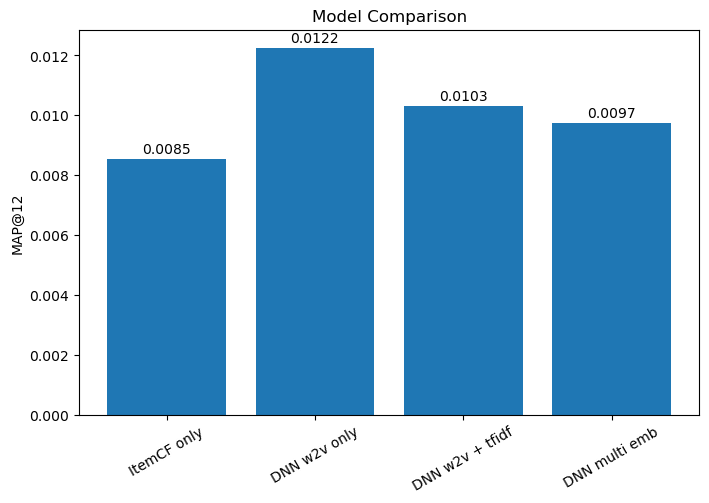

In [139]:
import matplotlib.pyplot as plt
results = pd.DataFrame({
    "Model": [
        "ItemCF only",
        "DNN w2v only",
        "DNN w2v + tfidf",
        "DNN multi emb"
    ],
    "MAP@12": [
        map12_itemcf,
        map12_dnn_w2v_only,
        map12_dnn_model2,
        map12_dnn_model3
    ]
})
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["MAP@12"])

plt.xticks(rotation=30)
plt.ylabel("MAP@12")
plt.title("Model Comparison")

for i, v in enumerate(results["MAP@12"]):
    plt.text(i, v + 0.0002, f"{v:.4f}", ha="center")

plt.show()

## 6 Limitation and Future work

Due to time constraints, this work does not fully utilize the entire user behavior sequences. Instead, only a limited history window is used, which may miss long-term user preferences. In addition, the train/validation split is relatively simple and does not fully simulate a realistic online recommendation setting; more refined strategies such as strict temporal splitting could provide more reliable evaluation.

Another limitation is the presence of strong long-tail effects and data sparsity. Many items and users have very few interactions, which makes it difficult for collaborative filtering and embedding-based methods to learn robust representations. This issue may lead to suboptimal performance, especially for cold or less active users and items.

Furthermore, this project mainly relies on textual and interaction-based features, without incorporating richer modalities such as item images. Visual information could provide complementary signals for understanding item similarity and user preferences, and its absence may limit the overall recommendation quality.

Future work could explore using LightGBM for reranking, as it is well-suited for combining heterogeneous features such as itemCF scores and user/item statistics. Compared to DNNs, it may better capture feature interactions and improve MAP@K.

Finally, improving negative sampling (e.g., using hard negatives) may help align training with the ranking objective and further enhance performance.

Our results suggest that increasing model complexity does not necessarily improve performance, highlighting the importance of feature design and training strategy.

## 7. Appendix

github link: 
https://github.com/Wolke926/CSCE-676-data-mining-project

Resouce Declaration